# Import statements

In [2]:
import sys
sys.path.append("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork")

from IPython.display import display, HTML, Markdown
import murraylab_tools.echo as mt_echo
import os.path
import pandas as pd
from murraylab_tools.echo.echo_functions import echo_round
import os.path
import math

import matplotlib.pyplot as plt

import os

import numpy as np

import itertools


In [2]:
# get the working directory
os.getcwd()

'/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/examples/20250801_ID_384'

In [3]:
INPUT_DIR = os.path.join(os.getcwd(), "inputs")

OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")

# create the output directory if it does not exist
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

if not os.path.exists(INPUT_DIR):
    os.makedirs(INPUT_DIR)

# Input Spreadsheet

In [4]:
# Read the CSV file
df = pd.read_csv(os.path.join(INPUT_DIR, "ID_96w_transfections_Aug_22_2025.csv"), skiprows=1)
# Define the columns to use
columns_to_use = [
    'plasmid concentration nM', '1.1', '2.1', '3.1', '4.1', '5.1', '6.1', '7.1', '8.1', '9.1', '10.1', '11.1', '12.1', '13.1', '14.1',
    '15.1', '16.1', '17.1', '18.1', '19.1', '20.1', '21.1', '22.1', '23.1', '24.1', '25.1', '26.1', '27.1', '28.1', '29.1', '30.1', '31.1',
    '32.1', '33.1', '34.1', '35.1', '36.1', '37.1', '38.1', '39.1', '40.1', '41.1', '42.1', '43.1', '44.1', '45.1', '46.1', '47.1', '48.1', '49.1',
    '50.1', '51.1', '52.1', '53.1', '54.1', '55.1', '56.1', '57.1', '58.1', '59.1', '60.1', '61.1', '62.1', '63.1', '64.1', '65.1', '66.1', '67.1',
    '68.1', '69.1', '70.1', '71.1', '72.1', '73.1', '74.1', '75.1', '76.1', '77.1', '78.1', '79.1', '80.1', '81.1', '82.1', '83.1', '84.1', '85.1',
    '86.1', '87.1', '88.1', '89.1', '90.1', '91.1', '92.1', '93.1', '94.1', '95.1', '96.1',
]

# Filter the DataFrame to include only the specified columns
df = df[columns_to_use]

# Drop rows where 'plasmid concentration nM' is NaN and specific rows by index
df = df[~df["plasmid concentration nM"].isna()]

df = df.drop([0, 1, 12])


# Transpose the DataFrame and reverse the order of columns
df = df.transpose()
df = df[df.columns[::-1]]

# Rename columns based on the first row of the transposed DataFrame
df = df.rename(columns=df.iloc[0])
df = df.drop(index=['plasmid concentration nM'])

df.columns

df

# Rename specific columns to 'concentration(nM)'
df = df.rename(columns={'pUC19 (maxi)' : 'concentration(nM).1',
                        'm169_GvpW': 'concentration(nM).2', 
                        'm168_GvpV': 'concentration(nM).3',
                        'm167_GvpN': 'concentration(nM).4',
                        'm166_GvpK': 'concentration(nM).5',
                        'm165_GvpJ': 'concentration(nM).6',
                        'm164_GvpG': 'concentration(nM).7',
                        'm163_GvpF': 'concentration(nM).8',
                        'm162_GvpA': 'concentration(nM).9'})

# List of inserts to add as columns
inserts = ['water', 'puc19', 'm169', 'm168', 'm167', 'm166', 'm165', 'm164', 'm163', 'm162']
df
# Insert each component column into the DataFrame
for i, insert in enumerate(inserts, start=1):
    df.insert(i * 2 - 1, f'component_{i-1}', insert)

# Reset index and set 'well_id' as index
df = df.reset_index(drop=True).set_index('well_id')

# Drop unnecessary columns
df = df.drop(columns=['component_0', 'Final volume of DNA before water (uL)'])

# Save the DataFrame to a CSV file
df.to_csv(os.path.join(INPUT_DIR, 'ID_96w_association.csv'))


# convert to 384-well format

In [6]:
map_384 = pd.read_csv(os.path.join(INPUT_DIR, "96_to_384_df.csv"))
map_384

random_seeds = [42, 43, 44]

def randomize_four_reps_96_to_384(df, map_384):
    df = df.reset_index()
    df.index.name = "sample_id"
    df.index = 's' + df.index.astype(str)
    df = df.reset_index()
    df = df.drop(columns=["well_id"])

    offset_1_wells = map_384[map_384['96_plate'] == "Plate 1"]["384_well"]
    offset2_wells = map_384[map_384['96_plate'] == "Plate 2"]["384_well"]
    offset3_wells = map_384[map_384['96_plate'] == "Plate 3"]["384_well"]
    offset4_wells = map_384[map_384['96_plate'] == "Plate 4"]["384_well"]


    assoc_384 = pd.DataFrame(columns=df.columns)

    plate_1 = df.copy()
    plate_1["well_id"] = offset_1_wells.values
    plate_1["offset_id"] = 1
    
    plate_2 = df.copy().sample(frac=1, random_state=42)
    plate_2["well_id"] = offset2_wells.values
    plate_2["offset_id"] = 2

    plate_3 = df.copy().sample(frac=1, random_state=43)
    plate_3["well_id"] = offset3_wells.values
    plate_3["offset_id"] = 3

    plate_4 = df.copy().sample(frac=1, random_state=44)
    plate_4["well_id"] = offset4_wells.values
    plate_4["offset_id"] = 4

    randomized_plate_384_formatted = pd.concat([plate_1.reset_index(drop=True), plate_2.reset_index(drop=True), plate_3.reset_index(drop=True), plate_4.reset_index(drop=True)], ignore_index=True)

    cols = ['well_id'] + [col for col in randomized_plate_384_formatted.columns if col != 'well_id']
    randomized_plate_384_formatted = randomized_plate_384_formatted[cols]
    
    
    
    return randomized_plate_384_formatted

In [7]:
assoc_384_well_replicates = randomize_four_reps_96_to_384(df, map_384)

print(assoc_384_well_replicates.groupby('sample_id').size().reset_index().rename(columns={0: 'count'})["count"].unique())
print(assoc_384_well_replicates.groupby('well_id').size().reset_index().rename(columns={0: 'count'})["count"].unique())


[4]
[1]


In [8]:
# this should yield a datatable of 96 things if randomization worked correctly
assoc_384_well_replicates.drop(columns=['well_id', 'offset_id']).drop_duplicates()

,sample_id,component_1,concentration(nM).1,component_2,concentration(nM).2,component_3,concentration(nM).3,component_4,concentration(nM).4,component_5,concentration(nM).5,component_6,concentration(nM).6,component_7,concentration(nM).7,component_8,concentration(nM).8,component_9,concentration(nM).9
0,s0,puc19,12.0469,m169,0.0694,m168,0.0694,m167,0.0694,m166,0.0694,m165,0.0694,m164,0.0694,m163,0.2778,m162,2.7778
1,s1,puc19,12.0748,m169,0.0694,m168,0.0694,m167,0.0694,m166,0.0694,m165,0.0694,m164,0.2778,m163,0.0694,m162,2.7778
2,s2,puc19,12.0462,m169,0.0694,m168,0.0694,m167,0.0694,m166,0.0694,m165,0.2778,m164,0.0694,m163,0.0694,m162,2.7778
3,s3,puc19,12.0679,m169,0.0694,m168,0.0694,m167,0.0694,m166,0.2778,m165,0.0694,m164,0.0694,m163,0.0694,m162,2.7778
4,s4,puc19,12.0381,m169,0.0694,m168,0.0694,m167,0.2778,m166,0.0694,m165,0.0694,m164,0.0694,m163,0.0694,m162,2.7778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,s91,puc19,10.1412,m169,0.2778,m168,0.2778,m167,0.2778,m166,0.2778,m165,0.0694,m164,0.2778,m163,0.2778,m162,2.7778
92,s92,puc19,10.1195,m169,0.2778,m168,0.2778,m167,0.2778,m166,0.0694,m165,0.2778,m164,0.2778,m163,0.2778,m162,2.7778
93,s93,puc19,10.1493,m169,0.2778,m168,0.2778,m167,0.0694,m166,0.2778,m165,0.2778,m164,0.2778,m163,0.2778,m162,2.7778
94,s94,puc19,10.1108,m169,0.2778,m168,0.0694,m167,0.2778,m166,0.2778,m165,0.2778,m164,0.2778,m163,0.2778,m162,2.7778


In [9]:
# should yield 384 unique well ids if randomization worked correctly
len(assoc_384_well_replicates["well_id"].unique())

384

In [10]:
assoc_384_well_replicates

,well_id,sample_id,component_1,concentration(nM).1,component_2,concentration(nM).2,component_3,concentration(nM).3,component_4,concentration(nM).4,...,concentration(nM).5,component_6,concentration(nM).6,component_7,concentration(nM).7,component_8,concentration(nM).8,component_9,concentration(nM).9,offset_id
0,A1,s0,puc19,12.0469,m169,0.0694,m168,0.0694,m167,0.0694,...,0.0694,m165,0.0694,m164,0.0694,m163,0.2778,m162,2.7778,1
1,A3,s1,puc19,12.0748,m169,0.0694,m168,0.0694,m167,0.0694,...,0.0694,m165,0.0694,m164,0.2778,m163,0.0694,m162,2.7778,1
2,A5,s2,puc19,12.0462,m169,0.0694,m168,0.0694,m167,0.0694,...,0.0694,m165,0.2778,m164,0.0694,m163,0.0694,m162,2.7778,1
3,A7,s3,puc19,12.0679,m169,0.0694,m168,0.0694,m167,0.0694,...,0.2778,m165,0.0694,m164,0.0694,m163,0.0694,m162,2.7778,1
4,A9,s4,puc19,12.0381,m169,0.0694,m168,0.0694,m167,0.2778,...,0.0694,m165,0.0694,m164,0.0694,m163,0.0694,m162,2.7778,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,P16,s3,puc19,12.0679,m169,0.0694,m168,0.0694,m167,0.0694,...,0.2778,m165,0.0694,m164,0.0694,m163,0.0694,m162,2.7778,4
380,P18,s59,puc19,11.2797,m169,0.2778,m168,0.0694,m167,0.0694,...,0.2778,m165,0.2778,m164,0.0694,m163,0.0694,m162,2.7778,4
381,P20,s45,puc19,9.7445,m169,0.2778,m168,0.2778,m167,0.2778,...,0.2778,m165,0.2778,m164,0.2778,m163,0.2778,m162,2.7778,4
382,P22,s35,puc19,11.2753,m169,0.0694,m168,0.0694,m167,0.0694,...,0.2778,m165,0.2778,m164,0.0694,m163,0.2778,m162,2.7778,4


In [11]:
assoc_384_well_replicates.to_csv(os.path.join(INPUT_DIR, 'ID_384w_association_with_randomization_mapping.csv'), index=False)
assoc_384_well_replicates.drop(columns=['sample_id', "offset_id"]).to_csv(os.path.join(INPUT_DIR, 'ID_384w_association.csv'), index=False)

# Clear source plate


In [12]:
import pandas as pd

df = pd.read_csv(os.path.join(INPUT_DIR, "source_plate.dat"), delimiter=',', header=None)
df = df.iloc[0:0]
df.to_csv(os.path.join(INPUT_DIR, "source_plate.dat"), index=False, header=False)

# Output Spreadsheet

In [13]:
#relevent input and output files

stock_file = os.path.join(INPUT_DIR, "input_source_plate.csv")
assoc_pre_file = os.path.join(INPUT_DIR, "ID_384w_association.csv")
assoc_name = os.path.join(os.path.join(OUTPUT_DIR, "ID_082825_echo_picklist.csv"))
plate_file  = os.path.join(INPUT_DIR, "source_plate.dat") 

In [14]:
# make our materials and add them to a source plate using the SourcePlate objects and EchoSourceMaterial objects

# read in the source plate file
source_plate_df = pd.read_csv(stock_file)

#create a source well plate object
source_well_plate = mt_echo.SourcePlate(filename = plate_file, SPtype='384PP_AQ_BP', SPname="384_source_c1", reuse_wells=True)

# iterate over the source plate file rows and create materials. Then add those materials to a well in the source plate instance.
for index, row in source_plate_df.iterrows():
   source_well_plate.add_material_to_well(well=row.Location, material = mt_echo.EchoSourceMaterial(name=row.Name, concentration=row.Concentration, length=row.Length, units=row.Units), volume=31000)
   print(row.Location)

# create the EchoRun experiment with our source plate instance.
assoc_echo_calculator = mt_echo.EchoRun(DPtype= "Axygen 384", plate=source_well_plate)

# make the materials in the experiment known
unique_materials_df = source_plate_df.drop_duplicates("Name", keep='first')
for index, row in unique_materials_df.iterrows():
   assoc_echo_calculator.add_material(material = mt_echo.EchoSourceMaterial(name=row.Name, concentration=row.Concentration, length=row.Length, units=row.Units))
   print(row.Name)
  

B2
B4
B6
B8
B10
B12
B14
B16
B18
D2
D4
D6
D8
D10
D12
D14
F2
F4
F6
F8
F10
F12
F14
H2
H4
H6
H8
H10
H12
H14
H16
J2
J4
J6
J8
J10
J12
J14
L2
L4
L6
L8
L10
L12
L14
N2
N4
N6
N8
N10
N12
N14
P2
P4
P6
P8
P10
P12
P14
P16
A22
A23
A24
B22
B23
B24
C22
C23
C24
D22
D23
D24
E22
E23
E24
F22
F23
F24
G22
G23
G24
H22
H23
H24
I22
I23
I24
J22
J23
J24
K22
K23
K24
L22
L23
L24
M22
M23
M24
A1
B1
C1
D1
E1
F1
G1
H1
I1
J1
K1
L1
M1
N1
O1
P1
A3
B3
C3
D3
E3
F3
G3
H3
I3
J3
K3
L3
M3
N3
O3
P3
A5
B5
C5
D5
E5
F5
G5
H5
I5
J5
K5
L5
M5
N5
O5
P5
A7
B7
C7
D7
E7
F7
G7
H7
I7
J7
K7
L7
M7
N7
O7
P7
A9
B9
C9
D9
E9
F9
G9
H9
I9
J9
K9
L9
M9
N9
O9
P9
A11
B11
C11
D11
E11
F11
G11
H11
I11
J11
K11
L11
M11
N11
O11
P11
A13
10000
m162
m163
m164
m165
m166
m167
m168
m169
puc19
water


In [15]:
unique_materials_df

,Location,Name,Concentration,Length,Units
0,B2,m162,56.890,0,nM
9,D2,m163,4.551,0,nM
16,F2,m164,4.765,0,nM
23,H2,m165,4.392,0,nM
31,J2,m166,4.741,0,nM
38,L2,m167,4.451,0,nM
45,N2,m168,4.788,0,nM
52,P2,m169,4.419,0,nM
60,A22,puc19,58.251,0,nM
99,A1,water,1.000,0,x


In [16]:
# # make our materials and add them to a source plate using the SourcePlate objects and EchoSourceMaterial objects
# # this doesn't make a source plate with stuff in it, so the experiment will tell you what wells to fill.

# # read in the source plate file
# source_plate_df = pd.read_csv(stock_file)

# #create a source well plate object
# source_well_plate = mt_echo.SourcePlate(filename = plate_file, SPtype='384PP_Plus_AQ_BP', SPname="384_source_c1", reuse_wells=True)

# # create the EchoRun experiment with our source plate instance.
# assoc_echo_calculator = mt_echo.EchoRun(DPtype= "384 Plate", plate=source_well_plate)

# # make the materials in the experiment known
# for index, row in source_plate_df.iterrows():
#    assoc_echo_calculator.add_material(material = mt_echo.EchoSourceMaterial(name=row.Name, concentration=row.Concentration, length=row.Length, units=row.Units))
#    if index == 9: # break out of for loop when one copy of materials in the source plate are defined for the experiment
#       break

In [17]:
assoc_echo_calculator.rxn_vol = 5000.00 # PCR is large-volume!

# Define which column of the source file is what
name_col  = 1
conc_col  = 2
len_col   = 3
well_col  = 0
plate_col = 4

In [18]:
# Build a protocol, based on the association file.
assoc_echo_calculator.build_picklist_from_association_spreadsheet(input_filename= assoc_pre_file,
                                                                  well_column= 0,
                                                                  fill_with_water = True,
                                                                  water_name = "water"
                                                                  )


In [19]:
# Write the picklist
assoc_echo_calculator.write_picklist(assoc_name)

/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material m164 into well E15; are you sure you want to do this?
  warnings.warn(f"Requesting 0 volume from material {self.name}"
/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material m163 into well K17; are you sure you want to do this?
  warnings.warn(f"Requesting 0 volume from material {self.name}"
/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material m164 into well K19; are you sure you want to do this?
  warnings.warn(f"Requesting 0 volume from material {self.name}"
/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material m165 into w

# Trouble Shoot Section for Error that Says Negative Dimension Not Allowed.

This is because you have added more filled source wells than needed to the source plate. "Additional wells needed" then becomes negative

In [20]:
material_well_dict = {}
for mat_name in assoc_echo_calculator.material_dict:
    mat = assoc_echo_calculator.material_dict[mat_name]
    if mat:
        name, conc = mat.name, mat.concentration
        if mat.plate is None:
            raise Exception(f"Material '{mat}' doesn't have a plate " +\
                                "at plate initialization time.")
        print("Matieral name: " + mat.name)
        print("Material source concentration: " + str(mat.concentration))
        #print(mat.plate)
        echo_volume = mat.echo_volume_requested
        tot_available_vol = mat.plate.get_available_material(mat)
        volume_additional = echo_volume-tot_available_vol
        print("How much volue needed for run: " + str(echo_volume))
        n_source_wells = math.ceil(float(volume_additional) /  10000)
        print("Number of source wells needed additional: " + str(n_source_wells))
        print("Number of source wells needed: " + str(math.ceil(float(echo_volume) /  10000)))
        #wells_to_fill = mat.plate.request_source_wells(mat)
        
        

        # material_well_dict[(name, conc)] = wells_to_fill

        # if (name, conc) in mat.plate.materials_to_add:
        #     material_well_dict[(name, conc)] += \
        #                             mat.plate.materials_to_add[name, conc]

#assoc_echo_calculator.material_dict['m163'].concentration

Matieral name: m162
Material source concentration: 56.89
How much volue needed for run: 86400
Number of source wells needed additional: 9
Number of source wells needed: 9
Matieral name: m163
Material source concentration: 4.551
How much volue needed for run: 69300
Number of source wells needed additional: 7
Number of source wells needed: 7
Matieral name: m164
Material source concentration: 4.765
How much volue needed for run: 68000
Number of source wells needed additional: 7
Number of source wells needed: 7
Matieral name: m165
Material source concentration: 4.392
How much volue needed for run: 73700
Number of source wells needed additional: 7
Number of source wells needed: 8
Matieral name: m166
Material source concentration: 4.741
How much volue needed for run: 69200
Number of source wells needed additional: 7
Number of source wells needed: 7
Matieral name: m167
Material source concentration: 4.451
How much volue needed for run: 69400
Number of source wells needed additional: 7
Number 

# Checker

In [21]:
import pandas as pd

final_association = pd.read_csv(os.path.join(INPUT_DIR, "ID_384w_association.csv"))
output_association = pd.read_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/examples/20250801_ID_384/outputs/ID_082825_echo_picklist.csv_EchoInput.csv")


display(final_association.head())
display(output_association.head())

volume_final = 5000.00

,well_id,component_1,concentration(nM).1,component_2,concentration(nM).2,component_3,concentration(nM).3,component_4,concentration(nM).4,component_5,concentration(nM).5,component_6,concentration(nM).6,component_7,concentration(nM).7,component_8,concentration(nM).8,component_9,concentration(nM).9
0,A1,puc19,12.0469,m169,0.0694,m168,0.0694,m167,0.0694,m166,0.0694,m165,0.0694,m164,0.0694,m163,0.2778,m162,2.7778
1,A3,puc19,12.0748,m169,0.0694,m168,0.0694,m167,0.0694,m166,0.0694,m165,0.0694,m164,0.2778,m163,0.0694,m162,2.7778
2,A5,puc19,12.0462,m169,0.0694,m168,0.0694,m167,0.0694,m166,0.0694,m165,0.2778,m164,0.0694,m163,0.0694,m162,2.7778
3,A7,puc19,12.0679,m169,0.0694,m168,0.0694,m167,0.0694,m166,0.2778,m165,0.0694,m164,0.0694,m163,0.0694,m162,2.7778
4,A9,puc19,12.0381,m169,0.0694,m168,0.0694,m167,0.2778,m166,0.0694,m165,0.0694,m164,0.0694,m163,0.0694,m162,2.7778


,Source Plate,Source Plate Type,Source Well,Sample ID,Destination Plate Name,Destination Well,Transfer Volume,Sample Comment
0,384_source_c1,384PP_AQ_BP,B2,m162,Axygen 384,A1,250,Actual concentration: 2.84
1,384_source_c1,384PP_AQ_BP,B2,m162,Axygen 384,A3,250,Actual concentration: 2.84
2,384_source_c1,384PP_AQ_BP,B2,m162,Axygen 384,A5,250,Actual concentration: 2.84
3,384_source_c1,384PP_AQ_BP,B2,m162,Axygen 384,A7,250,Actual concentration: 2.84
4,384_source_c1,384PP_AQ_BP,B2,m162,Axygen 384,A9,250,Actual concentration: 2.84


In [22]:
echo_df = output_association.copy()
echo_df = echo_df[echo_df["Sample ID"] != "water"]
echo_df = echo_df[["Sample ID", "Destination Well", "Transfer Volume"]].groupby(["Destination Well", "Sample ID"]).sum().reset_index()
echo_df

,Destination Well,Sample ID,Transfer Volume
0,A1,m162,250
1,A1,m163,300
2,A1,m164,75
3,A1,m165,75
4,A1,m166,75
...,...,...,...
3371,P9,m166,75
3372,P9,m167,300
3373,P9,m168,75
3374,P9,m169,75


In [23]:

# make a copy of the association dataframe
df = final_association.copy()

# dictionary to define stock concentrations in nM of source wells
stock_dict = {}
for mat_name in assoc_echo_calculator.material_dict:
    mat = assoc_echo_calculator.material_dict[mat_name]
    stock_dict[mat.name] = mat.concentration

stock_dict.pop('water')

# dictionary for mapping plasmid names to association sheet columns

component_mapping = {
    'component_1': ['puc19', 'concentration(nM).1'],
    'component_2': ['m169', 'concentration(nM).2'],
    'component_3': ['m168', 'concentration(nM).3'],
    'component_4': ['m167', 'concentration(nM).4'],
    'component_5': ['m166', 'concentration(nM).5'],
    'component_6': ['m165', 'concentration(nM).6'],
    'component_7': ['m164', 'concentration(nM).7'],
    'component_8': ['m163', 'concentration(nM).8'],
    'component_9': ['m162', 'concentration(nM).9'],
}

# convert the association spreadsheet concentrations to volumes
# watch the indexing here, it could be wrong if you change the dataframe structure
for index, row in df.iterrows():
    for comp in component_mapping.keys():
        df.loc[index, component_mapping[comp][1]] = (volume_final* df.loc[index, component_mapping[comp][1]])/(stock_dict[component_mapping[comp][0]])
        # print(f"Row {index}, Column {i+1}: {df.loc[index, component_mapping[comp][1]]} uL")
        # print(f"stock_dict value: {stock_dict[component_mapping[comp][0]]}")

# make the format so everything is in two columns: Sample ID and Predicted Volume
comp_df_list = []
for comp in component_mapping.keys():
    comp_df = df.loc[:, ["well_id", comp, component_mapping[comp][1]]]
    comp_df = comp_df.rename(columns={"well_id": "Destination Well", comp: "Sample ID", component_mapping[comp][1]: "Predicted Volume"})
    comp_df_list.append(comp_df)

expected_df = pd.concat(comp_df_list, axis=0, ignore_index=True,)
expected_df = expected_df[expected_df["Predicted Volume"] > 0]

comparison_df = expected_df.merge(echo_df, on=["Destination Well", "Sample ID"], how="left", suffixes=('_expected', '_echo'))

comparison_df["percent_error"] = ((comparison_df["Transfer Volume"] - comparison_df["Predicted Volume"]) / comparison_df["Predicted Volume"] * 100).abs()


In [24]:
comparison_df.head()

,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error
0,A1,puc19,1034.050918,1025,0.875287
1,A3,puc19,1036.445726,1025,1.104325
2,A5,puc19,1033.990833,1025,0.869527
3,A7,puc19,1035.853462,1025,1.047780
4,A9,puc19,1033.295566,1025,0.802826


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


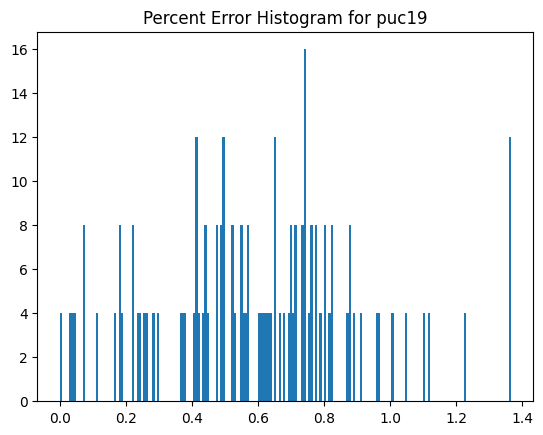

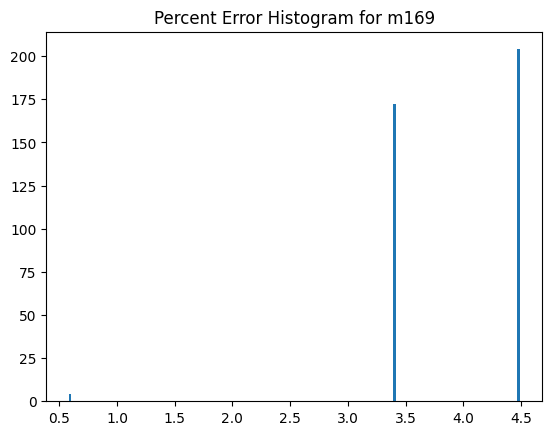

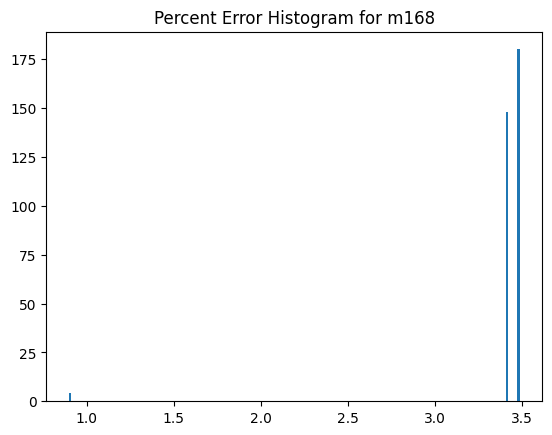

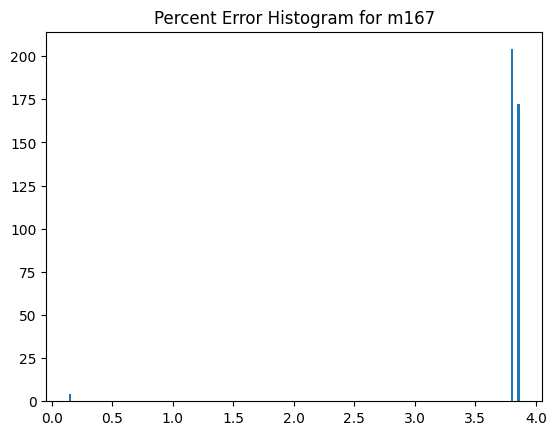

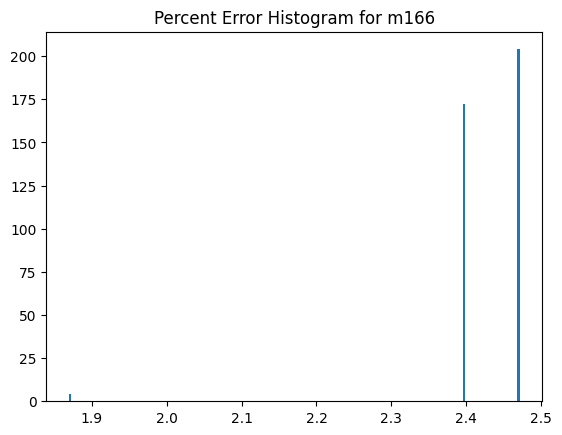

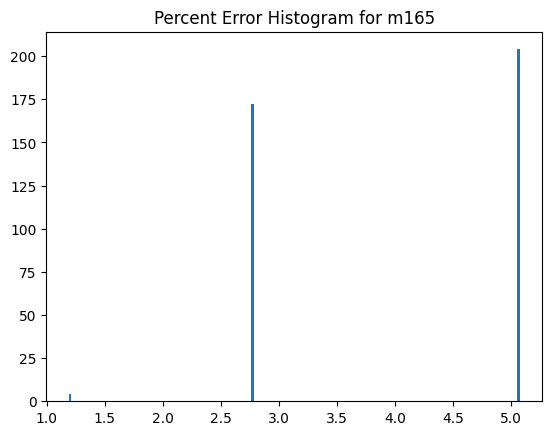

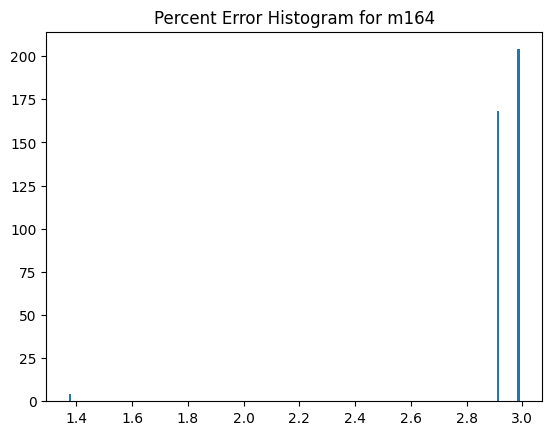

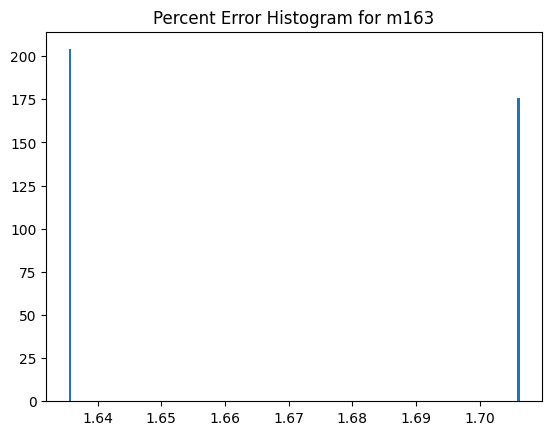

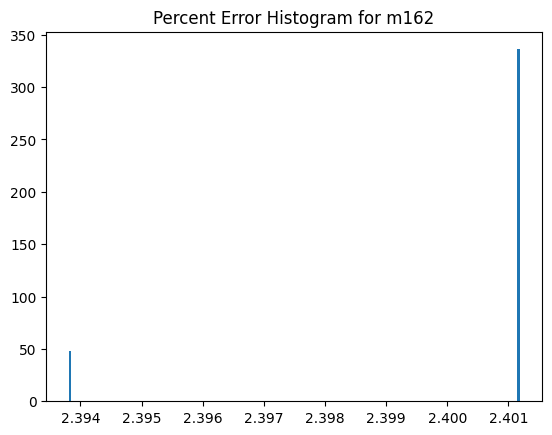

In [25]:
for comp in component_mapping.keys():
    comp_comparison_df = comparison_df[(comparison_df["Sample ID"] == component_mapping[comp][0])]
    display(comp_comparison_df[(comp_comparison_df["percent_error"] > 10)])
    plt.figure()

    plt.hist(comp_comparison_df['percent_error'], bins=200)
    plt.title(f"Percent Error Histogram for {component_mapping[comp][0]}")


# Check that all the source wells will not transfer more than 10 uL

In [26]:
echo_df = output_association.copy()
echo_df = echo_df[echo_df["Sample ID"] != "water"]
echo_df = echo_df[["Source Well", "Transfer Volume"]].groupby(["Source Well"]).sum().reset_index()
echo_df[echo_df["Transfer Volume"] > 10000]

,Source Well,Transfer Volume
